# BITUN

In [69]:
import pandas as pd
import numpy as np

df = pd.read_csv('DASS.csv')

<h1> Missing data imputation </h1>

<h2> 1.1 Complete Case Analysis </h2>

In [70]:
df_cca = df.dropna()

<h2> 1.2 Mean/Median/Mode Imputation </h2>

In [71]:

df['age_median'] = df['age'].fillna(df['age'].median())
df['gender_mode'] = df['gender'].fillna(df['gender'].mode()[0])

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\121074850.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_median'] = df['age'].fillna(df['age'].median())
C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\121074850.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['gender_mode'] = df['gender'].fillna(df['gender'].mode()[0])


<h2> 1.3 Random Sample Imputation </h2>

In [72]:

def random_sample_impute(df, variable):
    df[variable + '_random'] = df[variable]
    random_sample = df[variable].dropna().sample(df[variable].isnull().sum(), random_state=0)
    random_sample.index = df[df[variable].isnull()].index
    df.loc[df[variable].isnull(), variable + '_random'] = random_sample

<h2> 1.4 Replacement by Arbitrary Value </h2>

In [73]:
df['age_arbitrary'] = df['age'].fillna(99)

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\1804759179.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_arbitrary'] = df['age'].fillna(99)


<h2> 1.5 End of Distribution Imputation </h2>

In [74]:
extreme_value = df['age'].mean() + 3 * df['age'].std()
df['age_end_dist'] = df['age'].fillna(extreme_value)

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\3252416020.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_end_dist'] = df['age'].fillna(extreme_value)


<h2> 1.6 Missing Value Indicator  </h2>

In [75]:
df['age_nan_tag'] = np.where(df['age'].isnull(), 1, 0)

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\3859575863.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_nan_tag'] = np.where(df['age'].isnull(), 1, 0)


<h1> Categorical encoding </h1>

<h3> 2.1 One-Hot Encoding (OHE)</h3>

In [76]:
df_ohe = pd.get_dummies(df['country'], drop_first=True)


<h3> 2.2 Ordinal Encoding (Mapping levels) </h3>

In [77]:
education_map = {'Primary': 1, 'Secondary': 2, 'University': 3}
df['education_ordinal'] = df['education'].map(education_map)

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\608460764.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['education_ordinal'] = df['education'].map(education_map)


<h3> 2.3 Count and Frequency Encoding </h3>

In [78]:
freq_map = df['country'].value_counts().to_dict()
df['country_freq'] = df['country'].map(freq_map)

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\3195370072.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['country_freq'] = df['country'].map(freq_map)


<h3> 2.4 Target/Mean Encoding </h3>

In [79]:

stress_items = ['Q1A', 'Q6A', 'Q8A', 'Q11A', 'Q12A', 'Q14A', 'Q18A', 
                'Q22A', 'Q27A', 'Q29A', 'Q32A', 'Q33A', 'Q35A', 'Q39A']

df['stress_score'] = df[stress_items].sum(axis=1) - 14 

target_map = df.groupby(['country'])['stress_score'].mean().to_dict()
df['country_target_encoded'] = df['country'].map(target_map)

print(df[['country', 'country_target_encoded']].head())

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\2381603148.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['stress_score'] = df[stress_items].sum(axis=1) - 14


  country  country_target_encoded
0      IN               20.343049
1      US               22.071890
2      PL               22.843023
3      US               22.071890
4      MY               20.845545


C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\2381603148.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['country_target_encoded'] = df['country'].map(target_map)


<h3> 3.1 Logarithmic Transformation </h3>

In [80]:
import scipy.stats as stats

df['age_log'] = np.log(df['age'] + 1)

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\3510481979.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_log'] = np.log(df['age'] + 1)


<h3> 3.2 Reciprocal Transformation </h3>

In [81]:
df['age_reciprocal'] = 1 / (df['age'] + 1)

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\3161576123.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_reciprocal'] = 1 / (df['age'] + 1)


<h3> 3.3 Square-root Transformation </h3>

In [82]:
df['age_sqr'] = df['age']**(1/2)

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\2678162430.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_sqr'] = df['age']**(1/2)


<h3> 3.4 Exponential Transformation </h3>

In [83]:
df['age_exp'] = df['age']**(1.5)

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\2226402333.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_exp'] = df['age']**(1.5)


</h3> 3.5 Box-Cox Transformation </h3>

In [84]:
df['age_boxcox'], param = stats.boxcox(df['age'] + 1)

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\1693913710.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_boxcox'], param = stats.boxcox(df['age'] + 1)


<h1> Discretization </h1>

<h3> 4.1 Equal width discretization with pandas cut function </h3>

In [85]:
df['age_width'] = pd.cut(df['age'], bins=5)

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\1748071439.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_width'] = pd.cut(df['age'], bins=5)


<h3> 4.2 Equal frequency discretization with pandas qcut function </h3>

In [86]:
df['age_freq'] = pd.qcut(df['age'], q=5)

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\1881081733.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_freq'] = pd.qcut(df['age'], q=5)


<h3> 4.3 Domain knowledge discretization </h3>

In [87]:
bins = [0, 18, 35, 60, 100]
labels = ['Minor', 'Young Adult', 'Adult', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\4089411184.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)


<h1> Outlier Engineering </h1>

In [88]:
IQR = df['age'].quantile(0.75) - df['age'].quantile(0.25)
lower_bridge = df['age'].quantile(0.25) - (IQR * 1.5)
upper_bridge = df['age'].quantile(0.75) + (IQR * 1.5)

<h3> 5.1 Outlier removal </h3>

In [89]:
df_no_outliers = df[(df['age'] >= lower_bridge) & (df['age'] <= upper_bridge)]


<h3> 5.2 Treating outliers as missing values </h3>

In [90]:
df.loc[df['age'] > upper_bridge, 'age'] = np.nan

<h3> 5.3 Discretization </h3>

<h3> 5.4 Top/bottom/zero coding </h3>

In [91]:
df.loc[df['age'] > upper_bridge, 'age'] = upper_bridge
df.loc[df['age'] < lower_bridge, 'age'] = lower_bridge

# EDA 

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

<h3> Univariate </h3>

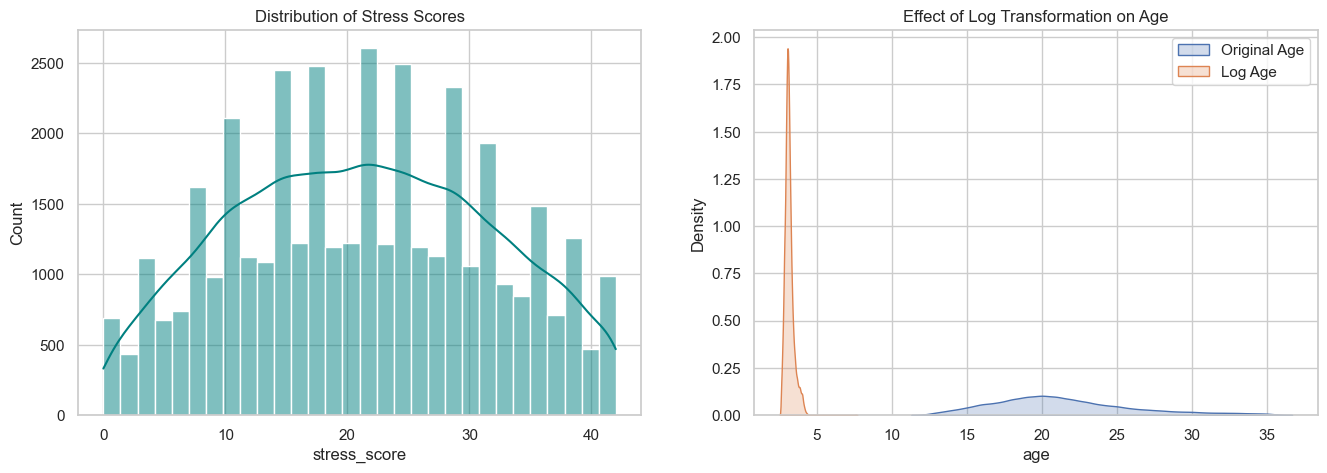

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['stress_score'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Stress Scores')

sns.kdeplot(df['age'], label='Original Age', ax=axes[1], fill=True)
sns.kdeplot(df['age_log'], label='Log Age', ax=axes[1], fill=True)
axes[1].set_title('Effect of Log Transformation on Age')
plt.legend()
plt.show()

<h3> Categorical </h3>

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\815067810.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')


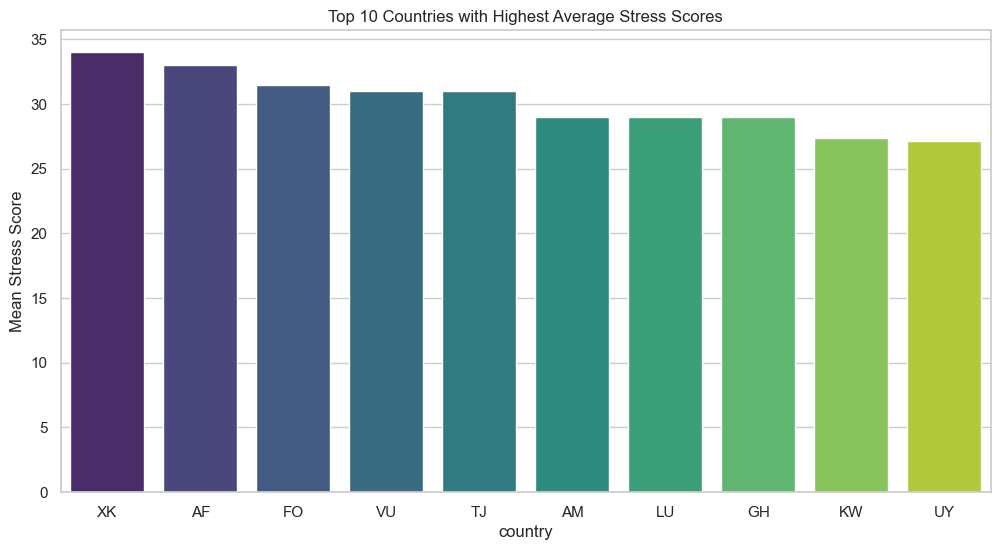

C:\Users\ALi\AppData\Local\Temp\ipykernel_5108\815067810.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='education', y='stress_score', data=df, palette='Set2')


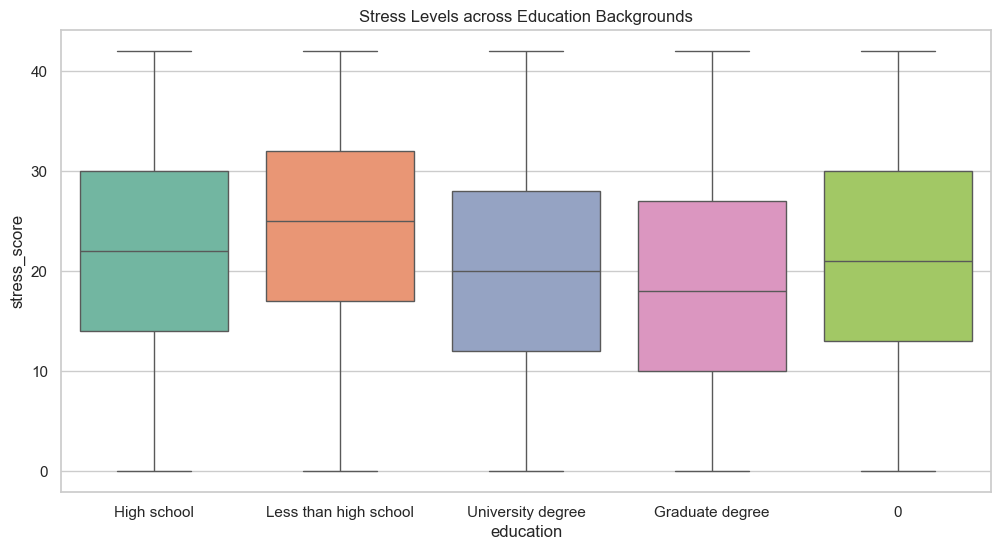

In [97]:
top_countries = df.groupby('country')['stress_score'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')
plt.title('Top 10 Countries with Highest Average Stress Scores')
plt.ylabel('Mean Stress Score')
plt.show()

sns.boxplot(x='education', y='stress_score', data=df, palette='Set2')
plt.title('Stress Levels across Education Backgrounds')
plt.show()